CAMPUS PLACEMENT PREDICTION USING MACHINE LEARNING

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA

In [3]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\campus_placement_data.csv")

DATA PREPROCESSING

In [4]:
df.head()

,student_id,gender,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,...,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
0,STU000001,Male,22,Tier 1,71.01,State,76.76,CBSE,Commerce,64.44,...,6.8,7.8,62.1,6.2,14,1,10,0,1,12.24
1,STU000002,Female,22,Tier 2,58.46,CBSE,57.62,State,Science,68.24,...,4.6,4.8,58.7,7.2,5,1,4,0,1,10.09
2,STU000003,Female,21,Tier 1,67.83,CBSE,65.67,State,Commerce,52.33,...,4.7,5.0,58.9,5.0,30,2,1,0,1,14.94
3,STU000004,Female,21,Tier 2,80.40,CBSE,77.15,State,Science,56.55,...,6.8,7.6,35.0,8.3,31,0,5,0,1,15.49
4,STU000005,Male,21,Tier 1,66.10,State,62.81,ICSE,Science,78.93,...,7.0,5.7,54.0,5.4,24,0,2,0,1,15.13


In [5]:
df.describe()

,age,ssc_percentage,hsc_percentage,degree_percentage,mba_percentage,internships_count,projects_count,certifications_count,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.55581,71.929885,71.831667,70.185520,22.853134,1.677490,3.295290,1.896330,5.982618,6.413043,59.913595,6.374366,9.964250,1.108080,2.931890,1.045870,0.844320,9.708429
std,1.50696,11.867225,13.903709,15.599274,31.610435,1.306627,1.870414,1.775324,1.948801,2.292634,17.772688,2.385099,11.953415,1.207242,1.937578,1.614606,0.362554,4.783668
min,18.00000,40.000000,40.000000,45.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.00000,63.870000,62.120000,58.090000,0.000000,1.000000,2.000000,0.000000,4.600000,4.800000,47.900000,4.700000,0.000000,0.000000,2.000000,0.000000,1.000000,8.510000
50%,21.00000,71.920000,71.860000,69.890000,0.000000,1.000000,3.000000,1.000000,6.000000,6.500000,60.000000,6.500000,3.000000,1.000000,3.000000,0.000000,1.000000,10.710000
75%,22.00000,80.030000,81.720000,81.840000,59.330000,2.000000,4.000000,3.000000,7.300000,8.200000,72.100000,8.300000,20.000000,2.000000,4.000000,2.000000,1.000000,12.710000
max,26.00000,100.000000,100.000000,100.000000,100.000000,5.000000,10.000000,8.000000,10.000000,10.000000,100.000000,10.000000,36.000000,5.000000,10.000000,10.000000,1.000000,24.220000


In [6]:
df.shape

(100000, 26)

In [7]:
df.columns

Index(['student_id', 'gender', 'age', 'city_tier', 'ssc_percentage',
       'ssc_board', 'hsc_percentage', 'hsc_board', 'hsc_stream',
       'degree_percentage', 'degree_field', 'mba_percentage', 'specialization',
       'internships_count', 'projects_count', 'certifications_count',
       'technical_skills_score', 'soft_skills_score', 'aptitude_score',
       'communication_score', 'work_experience_months', 'leadership_roles',
       'extracurricular_activities', 'backlogs', 'placed', 'salary_lpa'],
      dtype='object')

NULL VALUES

In [8]:
df.isnull().sum()

student_id                        0
gender                            0
age                               0
city_tier                         0
ssc_percentage                    0
ssc_board                         0
hsc_percentage                    0
hsc_board                         0
hsc_stream                        0
degree_percentage                 0
degree_field                      0
mba_percentage                    0
specialization                64965
internships_count                 0
projects_count                    0
certifications_count              0
technical_skills_score            0
soft_skills_score                 0
aptitude_score                    0
communication_score               0
work_experience_months            0
leadership_roles                  0
extracurricular_activities        0
backlogs                          0
placed                            0
salary_lpa                        0
dtype: int64

In [9]:
df['specialization'].fillna('None', inplace=True)

In [10]:
df['specialization'].value_counts()

specialization
None                   64965
Marketing & HR         11741
Finance & HR           11675
Marketing & Finance    11619
Name: count, dtype: int64

In [11]:
df['gender'].value_counts()

gender
Male      55027
Female    43028
Other      1945
Name: count, dtype: int64

DROPPING UNWANTED COLUMNS

In [12]:
df = df.drop(columns=["student_id", "salary_lpa"], errors="ignore")

EDA

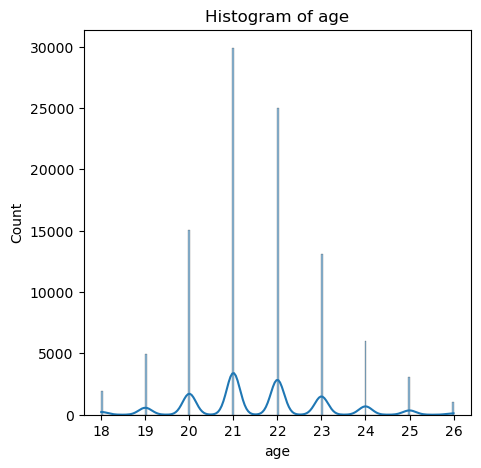

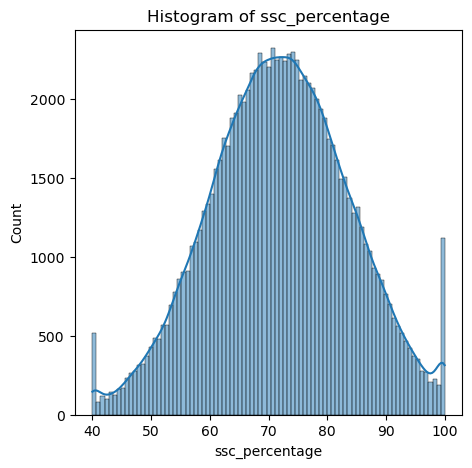

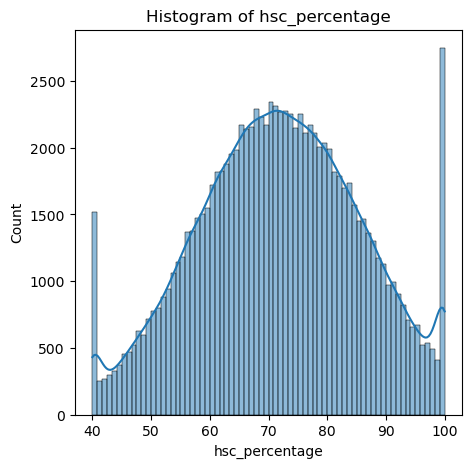

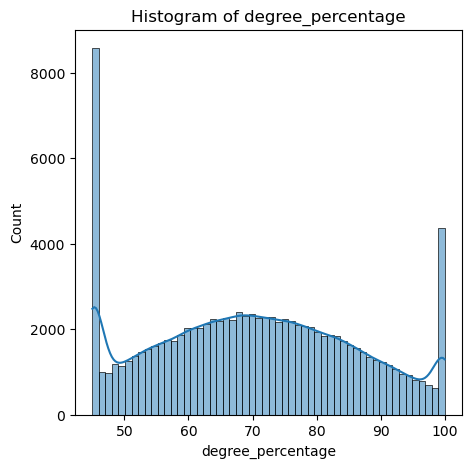

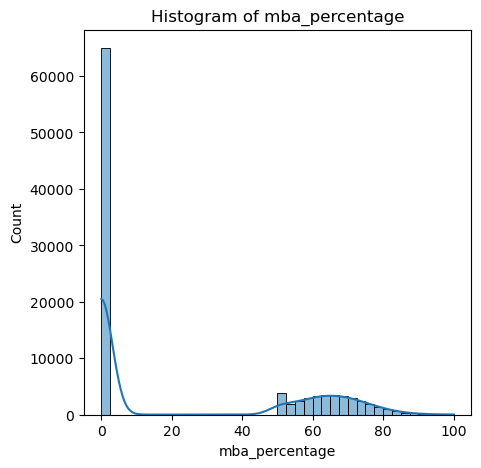

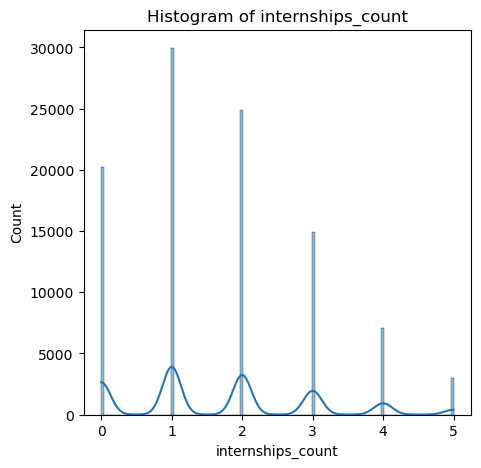

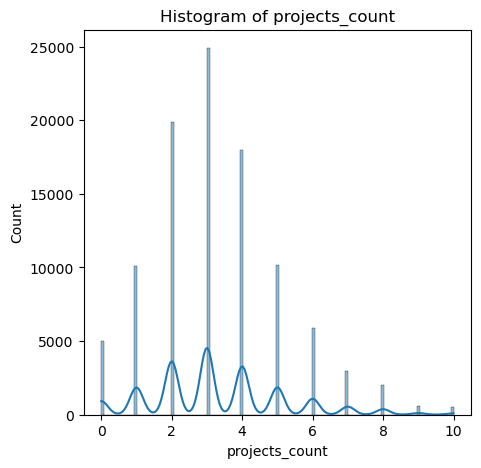

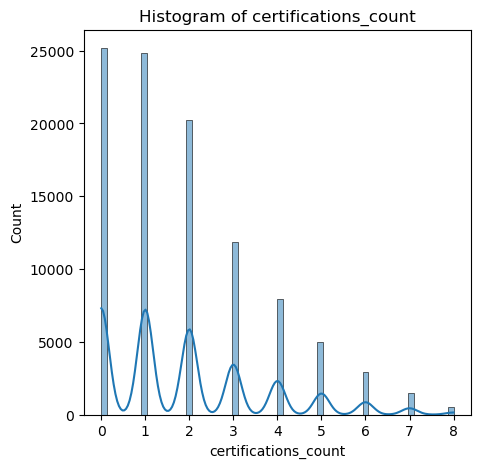

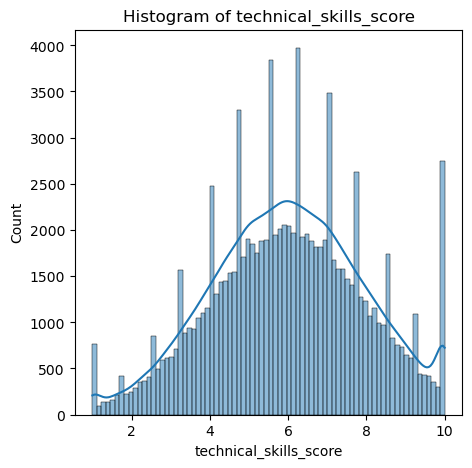

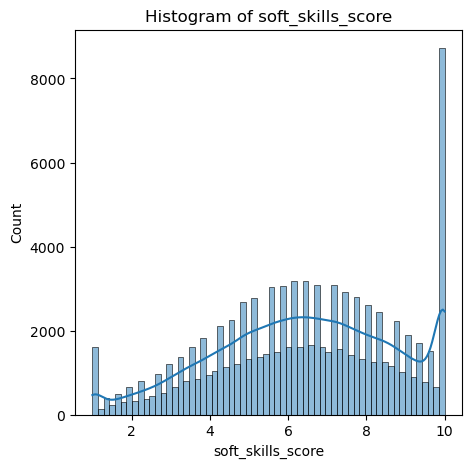

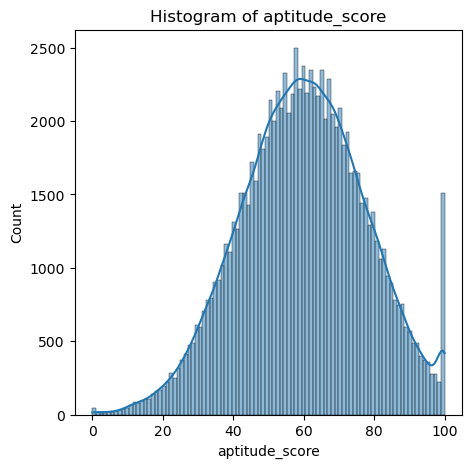

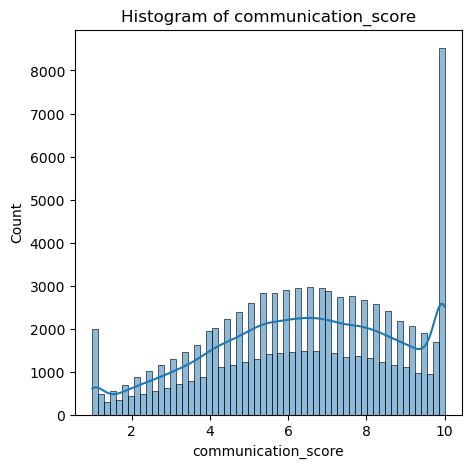

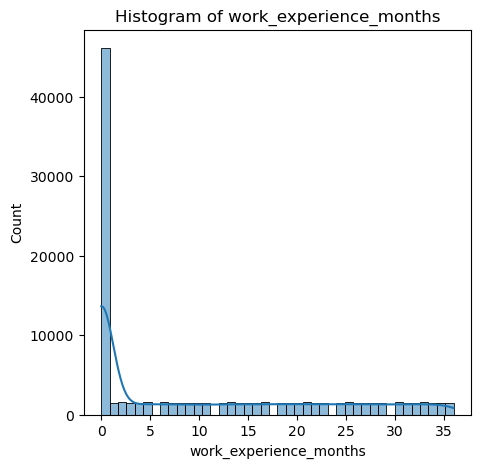

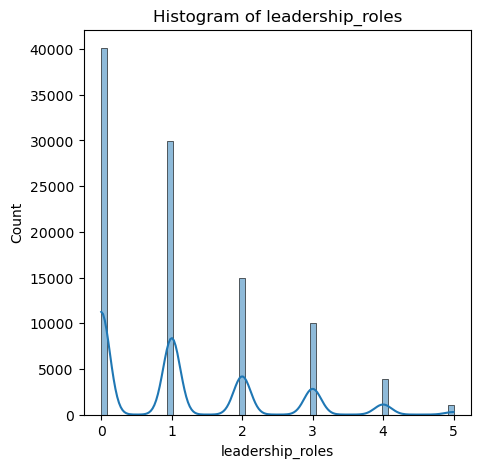

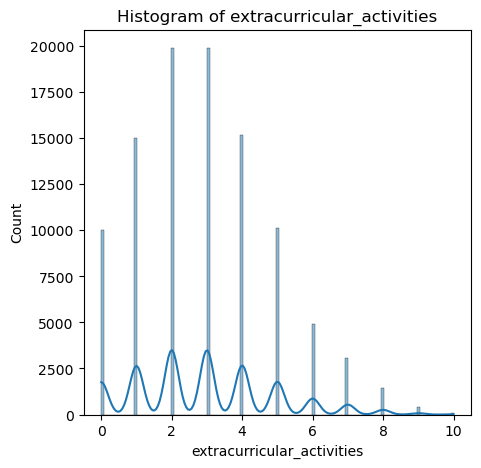

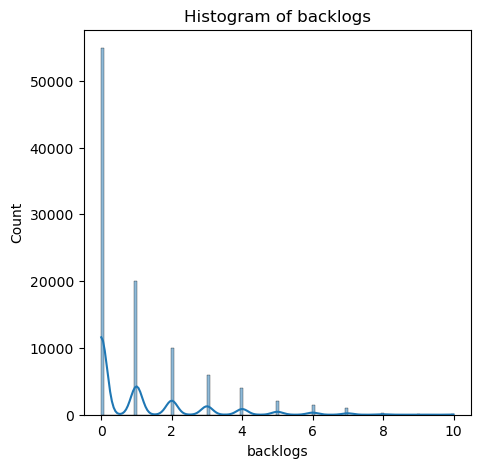

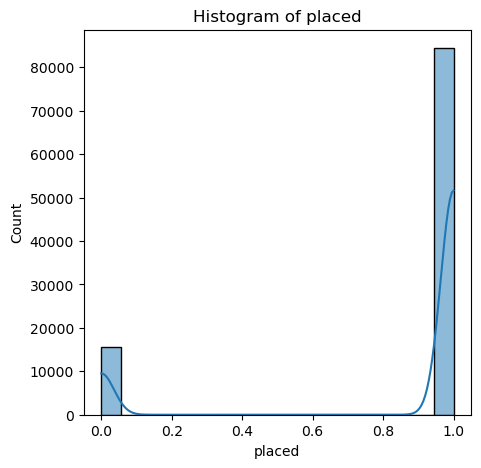

In [13]:
# # Distribution of numerical features
numeric_cols=df.select_dtypes(include=np.number).columns
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


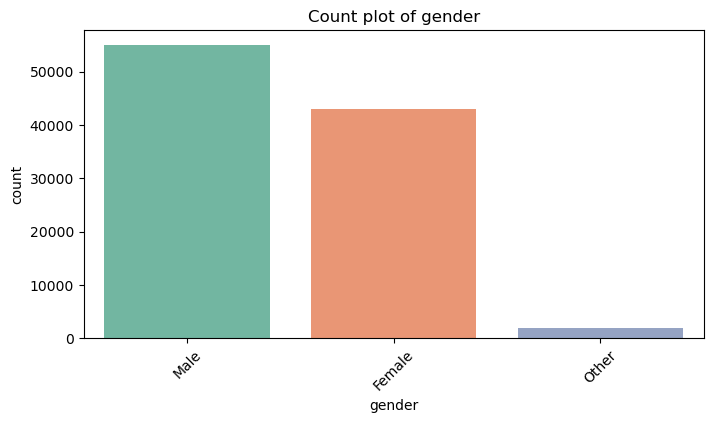

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


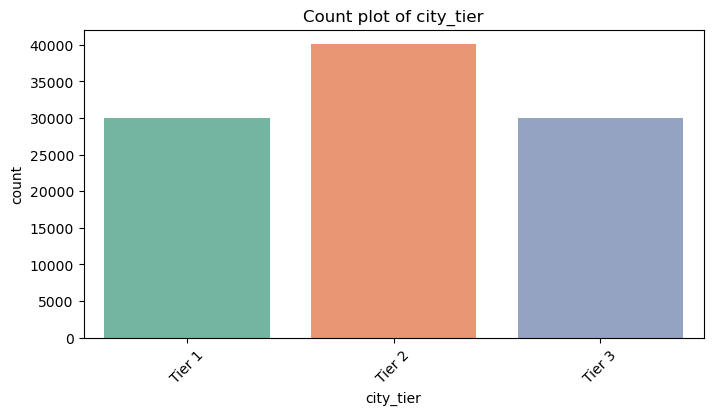

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


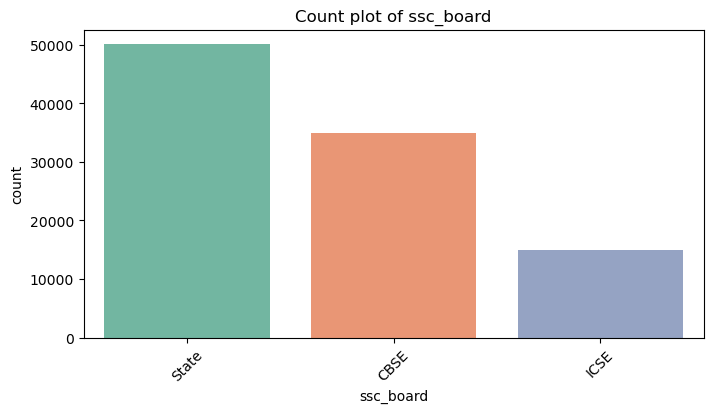

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


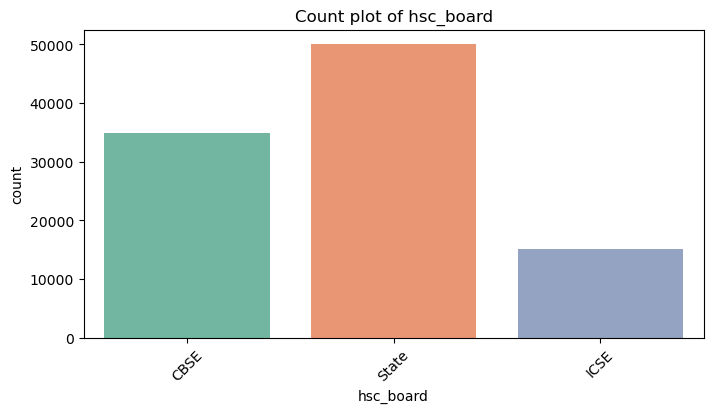

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


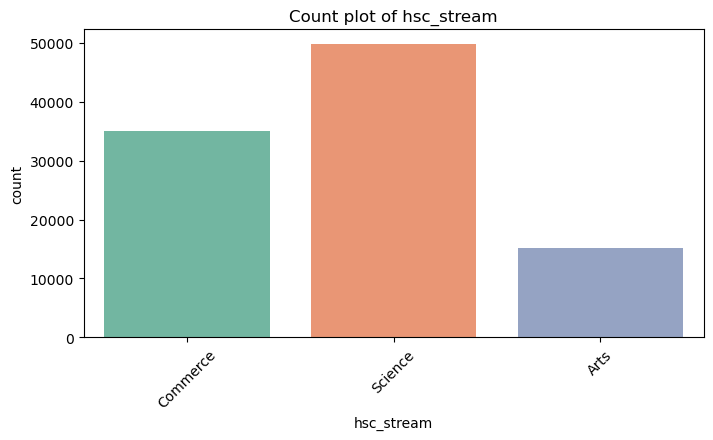

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


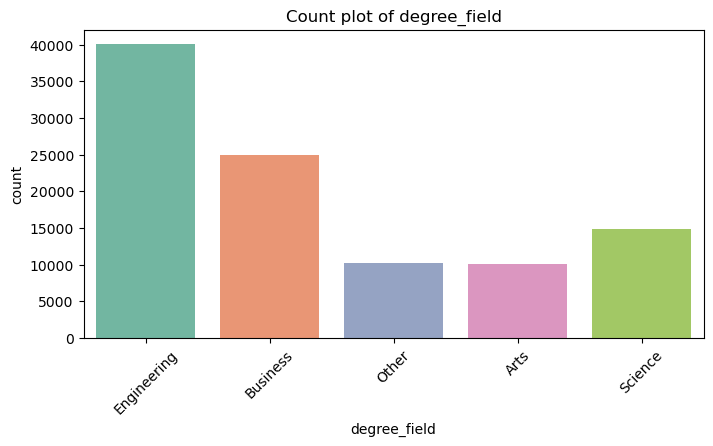

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\1708184557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


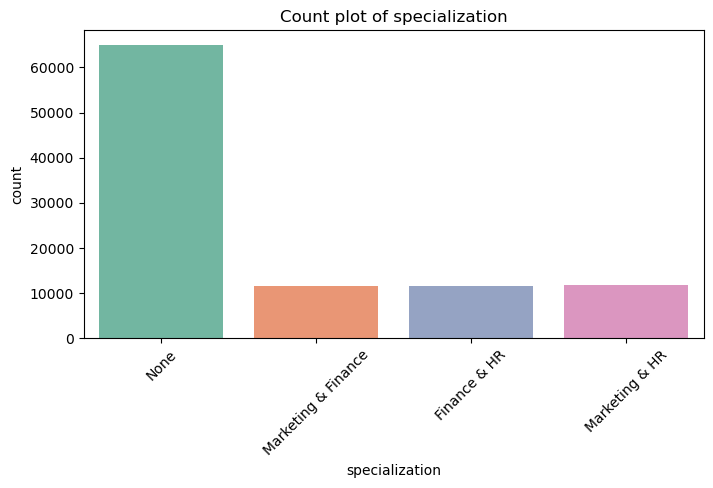

In [14]:
# Count plots for categorical features
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

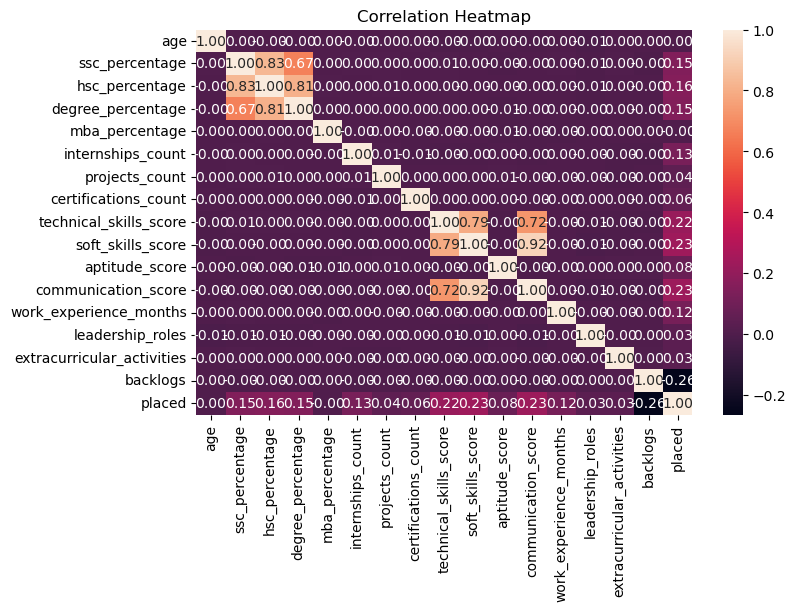

In [15]:
# Correlation heatmap
plt.figure(figsize=(8,5))
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

OUTLIER DETECTION

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


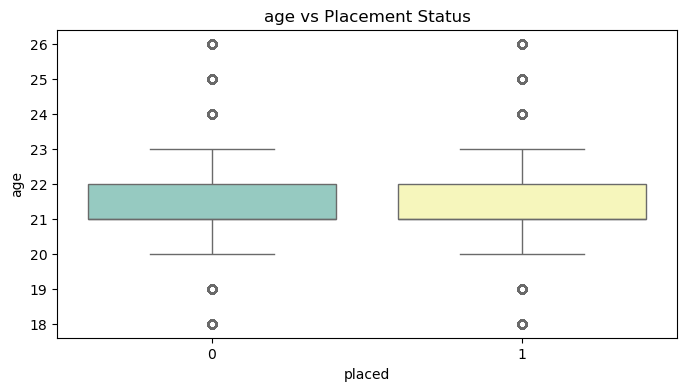

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


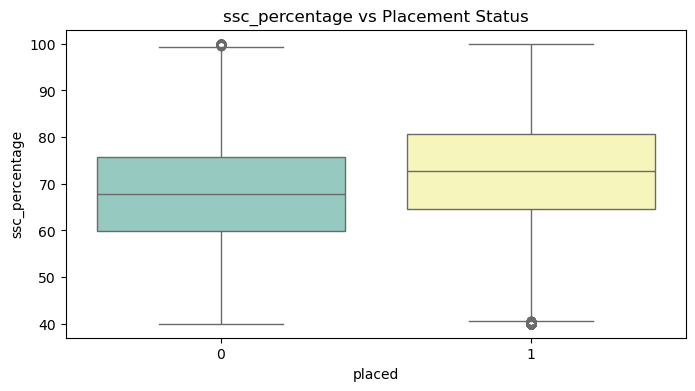

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


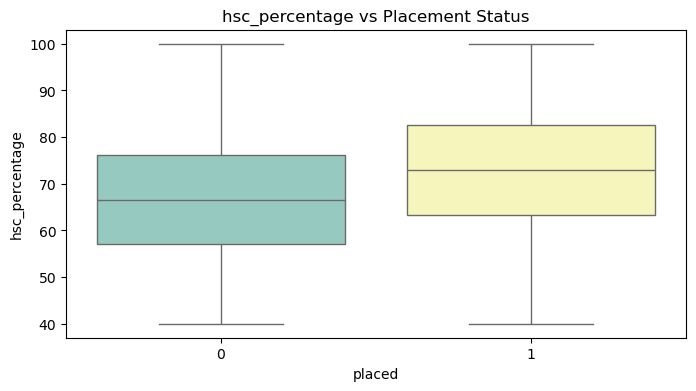

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


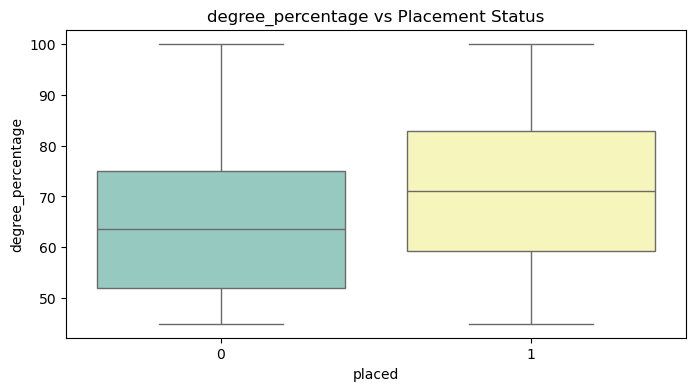

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


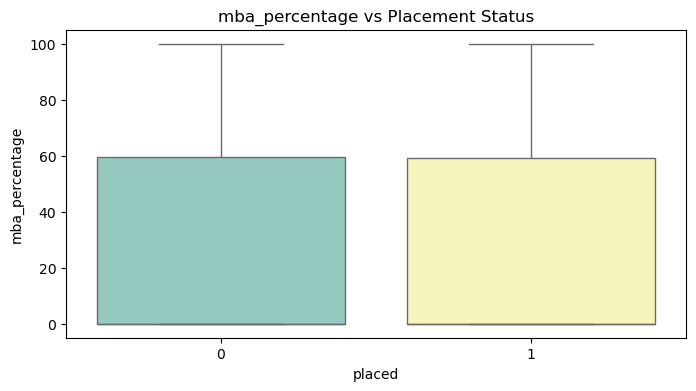

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


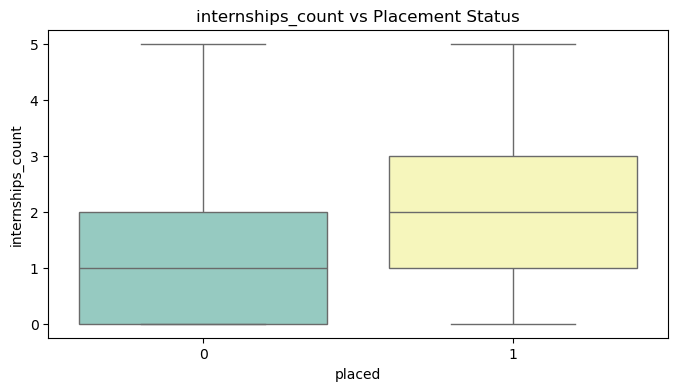

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


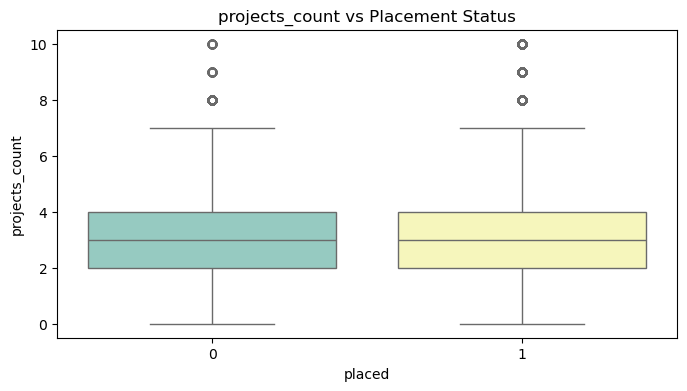

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


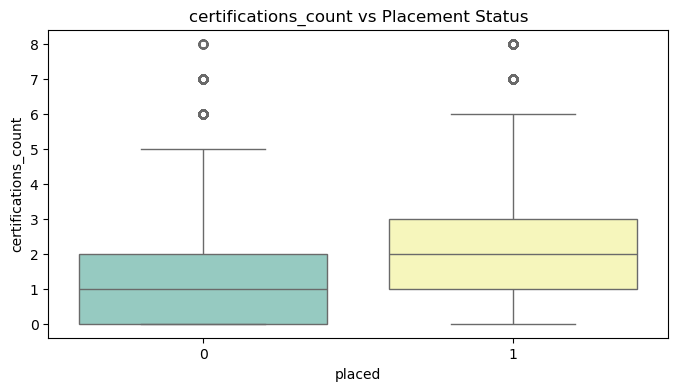

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


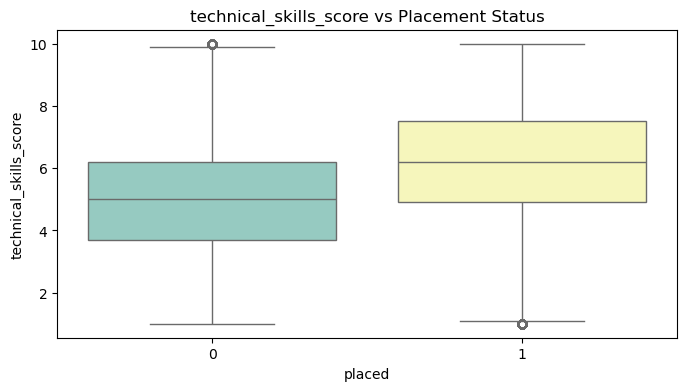

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


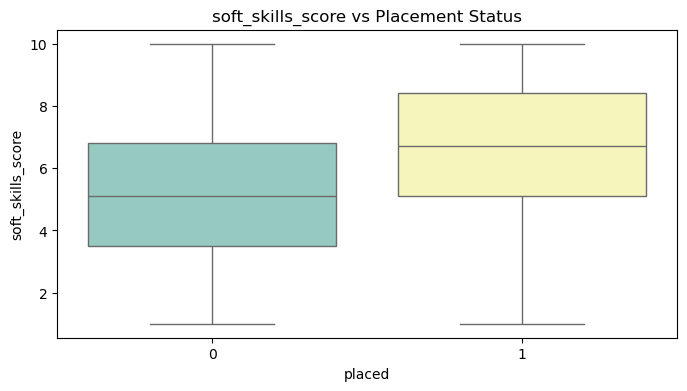

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


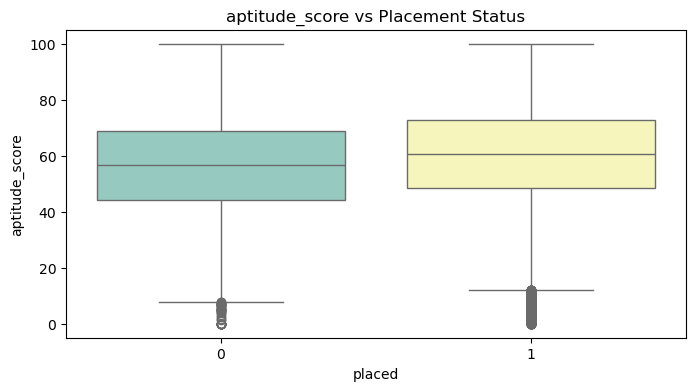

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


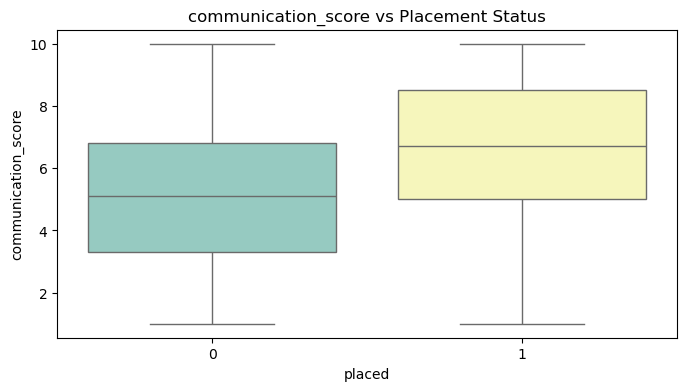

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


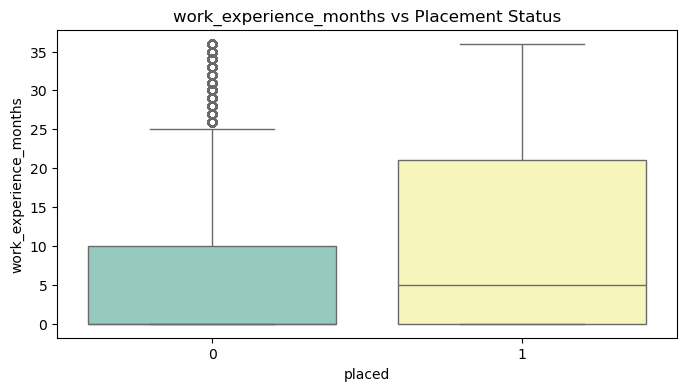

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


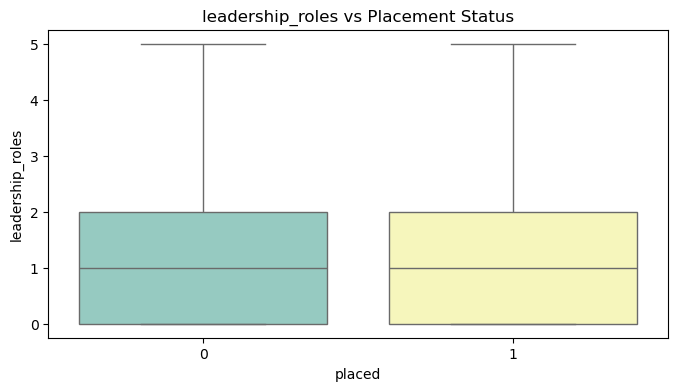

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


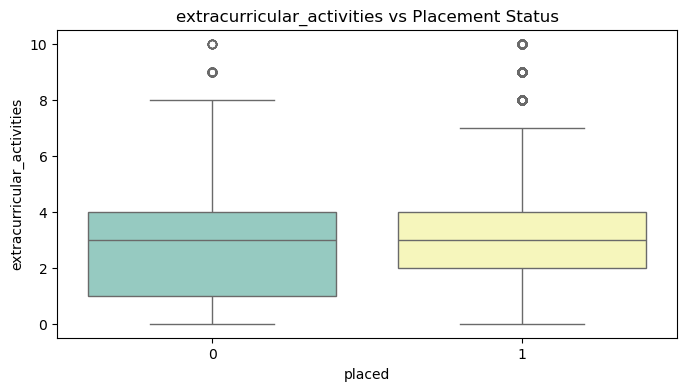

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


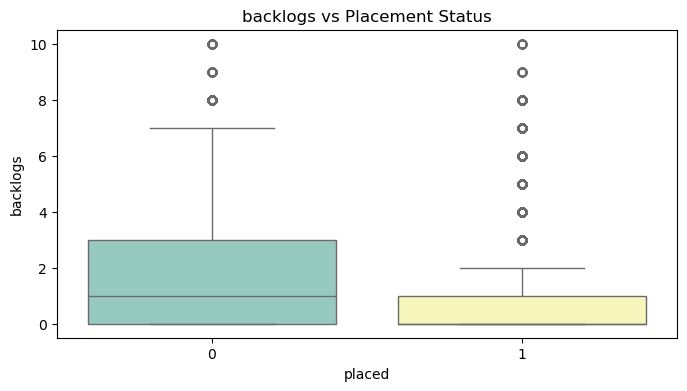

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7444\339444345.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="placed", y=col, data=df, palette="Set3")


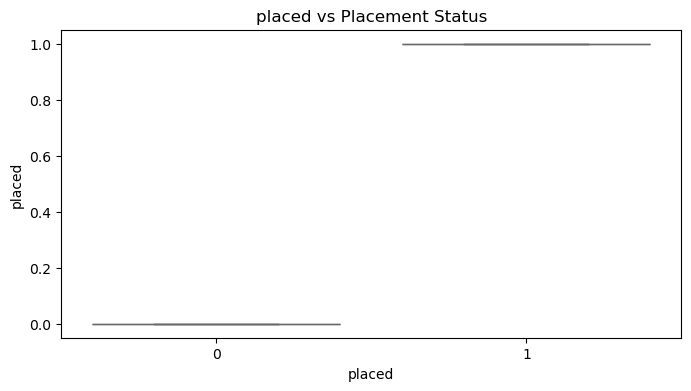

In [16]:
# Boxplots for numerical vs categorical (example: placement status vs scores)

num_cols = df.select_dtypes(include=np.number).columns

if "placed" in df.columns:
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x="placed", y=col, data=df, palette="Set3")
        plt.title(f"{col} vs Placement Status")
        plt.show()


MODEL BUILDING

In [17]:
# Define features (X) and target (y)
X = df.drop('placed', axis=1)
y = df['placed']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (75000, 23)
Test shape: (25000, 23)


In [19]:
num_cols = X_train.select_dtypes(include=["int64","float64","bool"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

ONEHOT ENCODIING, FEATURE SELECTION AND SMOTING

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [21]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

In [22]:
# First, preprocess the training data
X_train_preprocessed = preprocess.fit_transform(X_train)

# Define number of features to select
k_features = 20

# Perform feature selection
selector = SelectKBest(score_func=f_classif, k=min(k_features, X_train_preprocessed.shape[1]))
X_train_selected = selector.fit_transform(X_train_preprocessed, y_train)

# Get feature names after preprocessing
feature_names = preprocess.get_feature_names_out()

# Display selected features
selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]
selected_scores = selector.scores_[selected_mask]

selected_feature_df = pd.DataFrame({
    "feature": selected_feature_names,
    "score": selected_scores
}).sort_values("score", ascending=False).reset_index(drop=True)

print("TOP SELECTED FEATURES")
display(selected_feature_df)

# Also show features that were NOT selected (optional)
not_selected_features = feature_names[~selected_mask]
print(f"\nTotal features after preprocessing: {len(feature_names)}")
print(f"Selected: {len(selected_feature_names)}")
print(f"Not selected: {len(not_selected_features)}")


# Transform test data using the same preprocessing and selector
X_test_preprocessed = preprocess.transform(X_test)
X_test_selected = selector.transform(X_test_preprocessed)

print(f"\nTraining data shape (selected): {X_train_selected.shape}")
print(f"Test data shape (selected): {X_test_selected.shape}")

TOP SELECTED FEATURES


,feature,score
0,num__backlogs,5674.007285
1,num__soft_skills_score,4259.353181
2,num__communication_score,4081.925614
3,num__technical_skills_score,3773.726382
4,num__hsc_percentage,1903.441227
5,num__degree_percentage,1789.738925
6,num__ssc_percentage,1634.429189
7,num__internships_count,1192.577814
8,num__work_experience_months,1122.447793
9,num__aptitude_score,487.008945



Total features after preprocessing: 40
Selected: 20
Not selected: 20

Training data shape (selected): (75000, 20)
Test data shape (selected): (25000, 20)


 DECISION TREE

In [23]:
dt_pipe = ImbPipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(
        random_state=42, max_depth=6, min_samples_split=10, min_samples_leaf=5
    ))
])

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Decision Tree 
dt_pipe.fit(X_train, y_train)  
dt_pred = dt_pipe.predict(X_test)  
dt_proba = dt_pipe.predict_proba(X_test)[:, 1]  

print("=== Decision Tree ===")
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("ROC AUC:", roc_auc_score(y_test, dt_proba))

=== Decision Tree ===
[[ 1759  2133]
 [ 3393 17715]]
              precision    recall  f1-score   support

           0       0.34      0.45      0.39      3892
           1       0.89      0.84      0.87     21108

    accuracy                           0.78     25000
   macro avg       0.62      0.65      0.63     25000
weighted avg       0.81      0.78      0.79     25000

Accuracy: 0.77896
ROC AUC: 0.7439937435254428


 RANDOM FOREST

In [48]:
rf_pipe = ImbPipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ))
])

In [49]:
rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
print("\n=== Random Forest ===")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))


=== Random Forest ===
[[ 1469  2423]
 [ 1443 19665]]
              precision    recall  f1-score   support

           0       0.50      0.38      0.43      3892
           1       0.89      0.93      0.91     21108

    accuracy                           0.85     25000
   macro avg       0.70      0.65      0.67     25000
weighted avg       0.83      0.85      0.84     25000

Accuracy: 0.84536
ROC AUC: 0.8259497210158455


XGBOOST 

In [27]:
xgb_pipe = ImbPipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        random_state=42, n_jobs=-1
    ))
])

In [28]:
xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]
print("\n=== XGBoost ===")
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_proba))


=== XGBoost ===
[[ 1092  2800]
 [  880 20228]]
              precision    recall  f1-score   support

           0       0.55      0.28      0.37      3892
           1       0.88      0.96      0.92     21108

    accuracy                           0.85     25000
   macro avg       0.72      0.62      0.64     25000
weighted avg       0.83      0.85      0.83     25000

Accuracy: 0.8528
ROC AUC: 0.8265077635771672


SCALING

In [29]:
from sklearn.preprocessing import StandardScaler
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

LOGISTIC REGRESSION

In [30]:
from sklearn.linear_model import LogisticRegression
log_pipe = ImbPipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ))
])

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

log_pipe.fit(X_train, y_train)

log_pred = log_pipe.predict(X_test)
log_proba = log_pipe.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))
print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_proba))

=== Logistic Regression ===
[[ 2998   894]
 [ 5126 15982]]
              precision    recall  f1-score   support

           0       0.37      0.77      0.50      3892
           1       0.95      0.76      0.84     21108

    accuracy                           0.76     25000
   macro avg       0.66      0.76      0.67     25000
weighted avg       0.86      0.76      0.79     25000

Accuracy: 0.7592
ROC AUC: 0.8380407344716283


KNN

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = ImbPipeline([
    ("prep", preprocess), 
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ))
])

In [33]:
knn_pipe.fit(X_train, y_train)

knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("=== KNN ===")
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC AUC:", roc_auc_score(y_test, knn_proba))


=== KNN ===
[[ 2829  1063]
 [ 6826 14282]]
              precision    recall  f1-score   support

           0       0.29      0.73      0.42      3892
           1       0.93      0.68      0.78     21108

    accuracy                           0.68     25000
   macro avg       0.61      0.70      0.60     25000
weighted avg       0.83      0.68      0.73     25000

Accuracy: 0.68444
ROC AUC: 0.756871447940324


HYPERPARAMETER TUNING FOR XGBOOST

In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2]
}

search = RandomizedSearchCV(
    xgb_pipe,                     
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,                         
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Best params: {'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
# Best CV ROC-AUC: 0.839501706113225


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__subsample': 0.8, 'model__n_estimators': 400, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Best CV ROC-AUC: 0.839501706113225


In [46]:
best_model=search.best_estimator_

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Accuracy: 0.85864
# ROC AUC: 0.8377088084263362

#  RF was not chosen because it offered similar baseline results but required much more tuning time.

[[ 1050  2842]
 [  692 20416]]
              precision    recall  f1-score   support

           0       0.60      0.27      0.37      3892
           1       0.88      0.97      0.92     21108

    accuracy                           0.86     25000
   macro avg       0.74      0.62      0.65     25000
weighted avg       0.83      0.86      0.84     25000

Accuracy: 0.85864
ROC AUC: 0.8377088084263362


HORIZONTAL BARPLOT OF IMPORTANT FEATURES

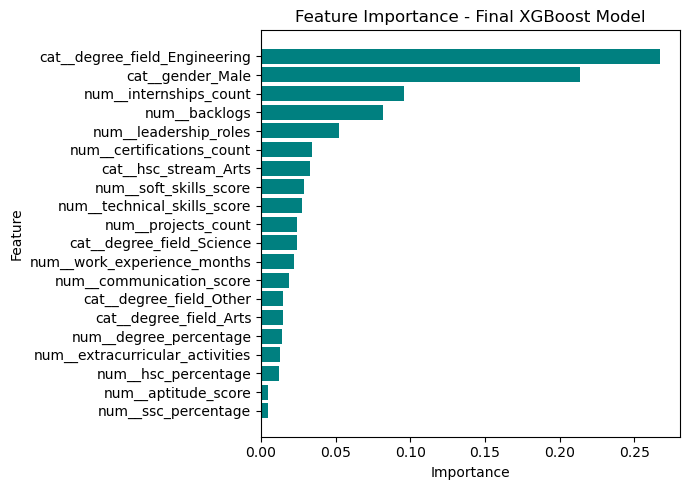

In [45]:
all_feature_names =best_model.named_steps["prep"].get_feature_names_out()
selected_feature_names = all_feature_names[best_model.named_steps["select"].get_support()]
importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": selected_feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(7, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="teal")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final XGBoost Model")
plt.tight_layout()
plt.show()


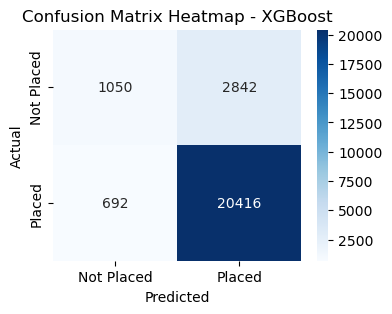

In [39]:
# prediction
y_pred = best_model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# heatmap
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Placed", "Placed"],
            yticklabels=["Not Placed", "Placed"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap - XGBoost")
plt.show()


In [47]:
# Create the performance dataframe
performance_df = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "XGBoost (Tuned)"],
    "Accuracy": [0.684, 0.759, 0.778, 0.854, 0.853, 0.8586],
    "ROC_AUC": [0.756, 0.838, 0.744, 0.825, 0.826, 0.8377]
})

print(performance_df)

                 Model  Accuracy  ROC_AUC
0                  KNN    0.6840   0.7560
1  Logistic Regression    0.7590   0.8380
2        Decision Tree    0.7780   0.7440
3        Random Forest    0.8540   0.8250
4              XGBoost    0.8530   0.8260
5      XGBoost (Tuned)    0.8586   0.8377


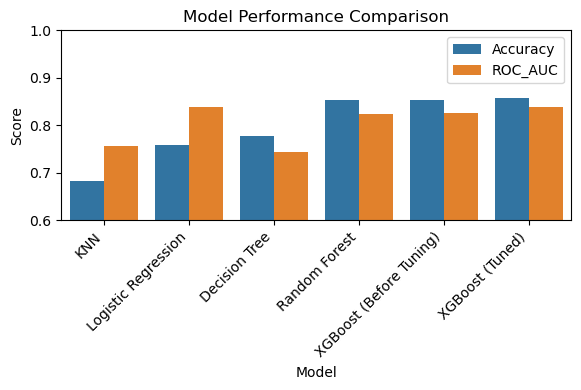

In [41]:
# Convert to long format for grouped barplot
plot_df = performance_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "ROC_AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(6,4))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.6, 1.0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [42]:
import pickle

# Save the trained model
with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# Save feature columns (important for consistency)
with open('columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns.tolist(), file)

In [50]:
# app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Page config
st.set_page_config(page_title="Campus Placement Predictor", layout="wide")

# Title
st.title("🎓 Campus Placement Prediction")
st.markdown("Predict whether a student will get placed based on their academic and personal attributes")

# Sidebar for navigation
st.sidebar.title("Navigation")
option = st.sidebar.radio("Choose an option", ["Predict Placement", "Model Info", "Data Overview"])

# Load and preprocess data
@st.cache_data
def load_data():
    df = pd.read_csv("campus_placement_data.csv")
    # Drop unnecessary columns
    df = df.drop(columns=["student_id", "salary_lpa"], errors="ignore")
    # Fill missing values
    df['specialization'].fillna('None', inplace=True)
    return df

@st.cache_resource
def train_model():
    df = load_data()
    
    # Encode categorical variables
    categorical_cols = ['gender', 'ssc_board', 'hsc_board', 'hsc_stream', 
                        'degree_field', 'specialization', 'city_tier']
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    
    # Features and target
    X = df.drop('placed', axis=1)
    y = df['placed']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    return model, scaler, label_encoders, accuracy, X.columns.tolist()

# Load or train model
try:
    model, scaler, label_encoders, accuracy, feature_columns = train_model()
    st.sidebar.success(f"✅ Model loaded! Accuracy: {accuracy:.2%}")
except Exception as e:
    st.error(f"Error loading model: {e}")
    st.stop()

# Prediction Page
if option == "Predict Placement":
    st.header("📊 Student Information")
    
    col1, col2 = st.columns(2)
    
    with col1:
        gender = st.selectbox("Gender", ["Male", "Female", "Other"])
        age = st.number_input("Age", min_value=18, max_value=26, value=21)
        city_tier = st.selectbox("City Tier", ["Tier 1", "Tier 2", "Tier 3"])
        ssc_percentage = st.slider("SSC Percentage", 40.0, 100.0, 70.0)
        ssc_board = st.selectbox("SSC Board", ["State", "CBSE", "ICSE"])
        hsc_percentage = st.slider("HSC Percentage", 40.0, 100.0, 70.0)
        hsc_board = st.selectbox("HSC Board", ["State", "CBSE", "ICSE"])
        hsc_stream = st.selectbox("HSC Stream", ["Science", "Commerce", "Arts"])
    
    with col2:
        degree_percentage = st.slider("Degree Percentage", 45.0, 100.0, 70.0)
        degree_field = st.selectbox("Degree Field", ["Engineering", "Science", "Commerce", "Arts"])
        mba_percentage = st.slider("MBA Percentage", 0.0, 100.0, 60.0)
        specialization = st.selectbox("Specialization", ["None", "Marketing & HR", "Finance & HR", "Marketing & Finance"])
        internships_count = st.number_input("Number of Internships", min_value=0, max_value=5, value=1)
        projects_count = st.number_input("Number of Projects", min_value=0, max_value=10, value=3)
        certifications_count = st.number_input("Number of Certifications", min_value=0, max_value=8, value=2)
        technical_skills_score = st.slider("Technical Skills Score", 1.0, 10.0, 6.0)
        soft_skills_score = st.slider("Soft Skills Score", 1.0, 10.0, 6.5)
        aptitude_score = st.slider("Aptitude Score", 0.0, 100.0, 60.0)
        communication_score = st.slider("Communication Score", 1.0, 10.0, 6.5)
        work_experience_months = st.number_input("Work Experience (months)", min_value=0, max_value=36, value=3)
        leadership_roles = st.number_input("Leadership Roles", min_value=0, max_value=5, value=1)
        extracurricular_activities = st.number_input("Extracurricular Activities", min_value=0, max_value=10, value=3)
        backlogs = st.number_input("Backlogs", min_value=0, max_value=10, value=0)
    
    # Create input dataframe
    input_data = pd.DataFrame([[
        gender, age, city_tier, ssc_percentage, ssc_board, hsc_percentage,
        hsc_board, hsc_stream, degree_percentage, degree_field, mba_percentage,
        specialization, internships_count, projects_count, certifications_count,
        technical_skills_score, soft_skills_score, aptitude_score,
        communication_score, work_experience_months, leadership_roles,
        extracurricular_activities, backlogs
    ]], columns=feature_columns)
    
    # Encode categorical variables
    for col in label_encoders:
        if col in input_data.columns:
            try:
                input_data[col] = label_encoders[col].transform(input_data[col])
            except ValueError:
                # Handle unseen labels
                input_data[col] = 0
    
    # Scale features
    input_scaled = scaler.transform(input_data)
    
    # Predict button
    if st.button("🔮 Predict Placement", type="primary"):
        prediction = model.predict(input_scaled)[0]
        probability = model.predict_proba(input_scaled)[0]
        
        st.markdown("---")
        if prediction == 1:
            st.success(f"✅ **Prediction: PLACED!** (Probability: {probability[1]:.1%})")
            st.balloons()
        else:
            st.error(f"❌ **Prediction: NOT PLACED** (Probability: {probability[0]:.1%})")
        
        # Show factors that influenced prediction
        st.subheader("📈 Key Factors for Improvement")
        st.info("""
        💡 **Tips to improve placement chances:**
        - Gain more internships and project experience
        - Improve technical and soft skills
        - Participate in extracurricular activities
        - Consider pursuing relevant certifications
        """)

# Model Info Page
elif option == "Model Info":
    st.header("📈 Model Information")
    
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Model Accuracy", f"{accuracy:.2%}")
        st.metric("Algorithm", "Random Forest Classifier")
    with col2:
        st.metric("Training Samples", "80,000")
        st.metric("Test Samples", "20,000")
    
    st.subheader("📊 Feature Importance")
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis', ax=ax)
    ax.set_title('Top 10 Most Important Features')
    st.pyplot(fig)
    
    st.subheader("🎯 About the Model")
    st.markdown("""
    This model predicts campus placement outcomes using:
    - **Random Forest Classifier** with 100 decision trees
    - Features include academic scores, skills, internships, and extracurricular activities
    - Data preprocessing includes label encoding for categorical variables and feature scaling
    """)

# Data Overview Page
elif option == "Data Overview":
    st.header("📊 Dataset Overview")
    
    df = load_data()
    
    st.subheader("Dataset Sample")
    st.dataframe(df.head(10))
    
    st.subheader("Dataset Info")
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Total Records", f"{len(df):,}")
        st.metric("Features", len(df.columns))
    with col2:
        st.metric("Placed Students", f"{df['placed'].sum():,}")
        st.metric("Placement Rate", f"{df['placed'].mean():.1%}")
    
    st.subheader("Placement Distribution")
    fig, ax = plt.subplots()
    df['placed'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], ax=ax)
    ax.set_ylabel('')
    ax.set_title('Placement Distribution')
    st.pyplot(fig)

2026-04-09 19:27:22.898 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 19:27:22.898 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 19:27:23.499 
  command:

    streamlit run c:\Users\lenovo\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-09 19:27:23.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 19:27:23.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 19:27:23.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 19:27:23.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when run